# NLP & ML Project: Recipe Classification
This notebook performs NLP-based classification of recipe texts into categories.

**Steps:**
1. Install required libraries.
2. Import necessary Python packages.
3. Set up configurations for visualization and warnings.


In [ ]:
# Run once in notebook to install libs (Colab or Jupyter)
!pip install -q nltk scikit-learn tqdm wordcloud umap-learn matplotlib seaborn

# Imports
import os
from pathlib import Path
import json
import re
from typing import List, Dict
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# NLP & ML
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import StratifiedKFold
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, roc_curve, auc)
from sklearn.preprocessing import LabelBinarizer

# Visualization extras
from wordcloud import WordCloud
import umap

import warnings
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")


# Upload Dataset
We will upload a ZIP file containing recipe text files. Each folder name represents the recipe category.

Steps:
1. Select your ZIP file.
2. Extract text files and read them into a pandas DataFrame.
3. Assign labels based on folder names.


In [ ]:
from google.colab import files
uploaded = files.upload()   # select your ZIP (e.g. MBA750.zip)


Saving MBA750.zip to MBA750.zip


In [ ]:
import zipfile
from pathlib import Path
import pandas as pd

zip_path = "MBA750.zip"   # change if your file has a different name

rows = []
with zipfile.ZipFile(zip_path, 'r') as z:
    for info in z.infolist():
        if info.filename.lower().endswith(".txt"):
            parts = Path(info.filename).parts
            # folder name (e.g. Cakes, Salads, etc.) becomes label
            label = parts[-2] if len(parts) >= 2 else "unknown"
            with z.open(info) as f:
                try:
                    text = f.read().decode('utf-8')
                except:
                    text = f.read().decode('latin-1')
            rows.append({"file_path": info.filename, "text": text, "label": label})

df = pd.DataFrame(rows)
print("✅ Loaded from ZIP:", len(df), "documents")
print(df['label'].value_counts())
df.head(3)


✅ Loaded from ZIP: 188 documents
label
Stews                48
Cakes                47
Salads               47
Pasta_and_Noodles    46
Name: count, dtype: int64


,file_path,text,label
0,Cakes/Angel Food Cake I.txt,"Beat egg whites until they form stiff peaks, a...",Cakes
1,Cakes/Apple Cake I.txt,Preheat oven to 350 degrees F (175 degrees C)....,Cakes
2,Cakes/Apple Cake IV.txt,Preheat oven to 350 degrees F (175 degrees C) ...,Cakes


# Text Preprocessing
We perform the following preprocessing steps:
1. Convert text to lowercase.
2. Tokenize text into words.
3. Remove stopwords.
4. Keep only alphabetic words.
5. Apply stemming (reduce words to root form).


In [ ]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('stopwords')

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Download resources
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('stopwords')

# Initialize lemmatizer and stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def lemmatize_tokenize(text: str):
    """Tokenize, clean, remove stopwords, and lemmatize."""
    if not isinstance(text, str):
        return []
    text = text.lower()
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t.isalpha() and t not in stop_words]
    lemmas = [lemmatizer.lemmatize(t) for t in tokens]
    return lemmas

# Demo on one sample
sample = df.loc[0,'text']
print("Original snippet:\n", sample[:250])
print("\nAfter lemmatization:\n", lemmatize_tokenize(sample)[:40])


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Original snippet:
 Beat egg whites until they form stiff peaks, and then add cream of tartar, vanilla extract, and almond extract.
Sift together flour, sugar, and salt. Repeat five times.
Gently combine the egg whites with the dry ingredients, and then pour into an ung

After lemmatization:
 ['beat', 'egg', 'white', 'form', 'stiff', 'peak', 'add', 'cream', 'tartar', 'vanilla', 'extract', 'almond', 'extract', 'sift', 'together', 'flour', 'sugar', 'salt', 'repeat', 'five', 'time', 'gently', 'combine', 'egg', 'white', 'dry', 'ingredient', 'pour', 'ungreased', 'inch', 'tube', 'pan', 'place', 'cake', 'pan', 'cold', 'oven', 'turn', 'oven', 'set']


# Visualizing Recipe Categories
1. Plot number of recipes per category.
2. Generate word clouds for each category to see frequent words.
3. Comparison of word clouds before and after lemmatization.

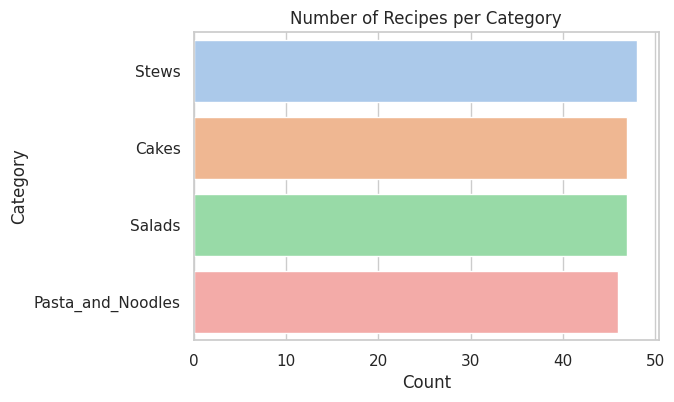

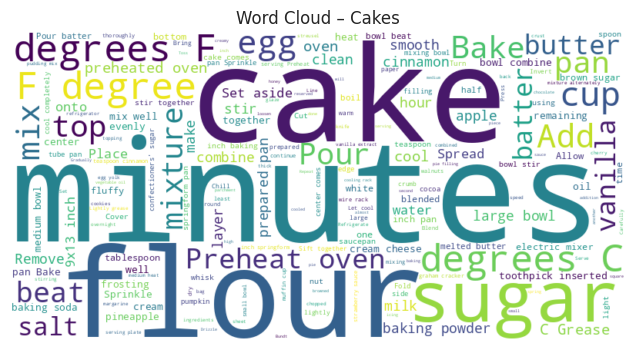

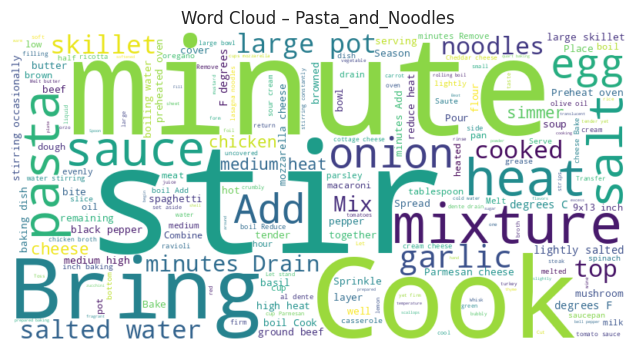

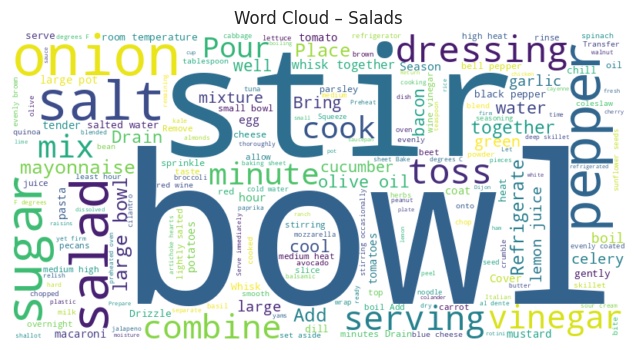

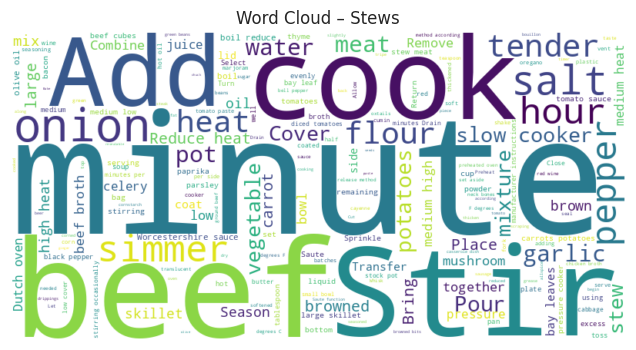

In [ ]:
### --- Data Visualization: Recipe Categories --- ###
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
sns.set(style="whitegrid")

# 1️. Category distribution
plt.figure(figsize=(6,4))
sns.countplot(y='label', data=df, order=df['label'].value_counts().index, palette='pastel')
plt.title("Number of Recipes per Category")
plt.xlabel("Count"); plt.ylabel("Category")
plt.show()

# 2️. Word cloud for each class
for label in df['label'].unique():
    text = " ".join(df[df['label']==label]['text'].tolist())
    wc = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(9,4))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Word Cloud – {label}")
    plt.show()


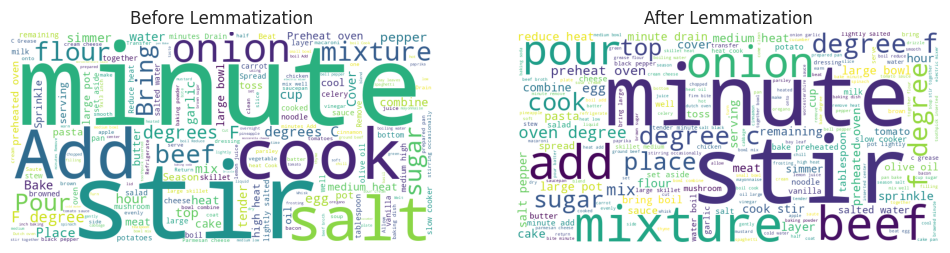

In [ ]:
# 3. Visualization of Lemmatization Effect ---

from wordcloud import WordCloud

original_text = " ".join(df['text'])
lemmatized_text = " ".join([" ".join(lemmatize_tokenize(t)) for t in df['text']])

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(WordCloud(width=800, height=400, background_color='white').generate(original_text))
plt.title("Before Lemmatization")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(WordCloud(width=800, height=400, background_color='white').generate(lemmatized_text))
plt.title("After Lemmatization")
plt.axis('off')
plt.show()


# 10-Fold Cross-Validation
We train and evaluate 3 classifiers using:
- **Naive Bayes**
- **Decision Tree**
- **Random Forest**

Two types of vectorization are compared:
1. **Boolean Bag-of-Words**
2. **TF-IDF**

Metrics calculated: Accuracy, Precision, Recall, F1, AUC


In [ ]:
from collections import defaultdict
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelBinarizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import numpy as np
import pandas as pd

# --- Define lemmatize_tokenize() before using this function ---
# Example:
# def lemmatize_tokenize(text):
#     # your tokenization + lemmatization logic
#     return tokens

def run_10fold_cv(df, vectorizer_type="boolean"):
    X = df['text'].values
    y = df['label'].values
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    results = defaultdict(list)

    # choose vectorizer
    def make_vectorizer():
        if vectorizer_type == "boolean":
            return CountVectorizer(binary=True, tokenizer=lemmatize_tokenize, ngram_range=(1, 2))
        else:
            return TfidfVectorizer(tokenizer=lemmatize_tokenize, ngram_range=(1, 2))

    models = {
        "Naive Bayes": MultinomialNB(),
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
    }

    lb = LabelBinarizer().fit(y)

    # --- Cross Validation ---
    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        vect = make_vectorizer()
        X_train_vec = vect.fit_transform(X_train)
        X_test_vec = vect.transform(X_test)
        y_test_bin = lb.transform(y_test)

        for name, model in models.items():
            clf = clone(model)
            clf.fit(X_train_vec, y_train)
            y_pred = clf.predict(X_test_vec)

            try:
                y_proba = clf.predict_proba(X_test_vec)
                auc = roc_auc_score(y_test_bin, y_proba, average='macro', multi_class='ovr')
            except Exception:
                auc = np.nan

            results[name].append({
                'accuracy': accuracy_score(y_test, y_pred),
                'precision': precision_score(y_test, y_pred, average='macro', zero_division=0),
                'recall': recall_score(y_test, y_pred, average='macro', zero_division=0),
                'f1': f1_score(y_test, y_pred, average='macro', zero_division=0),
                'auc': auc
            })

    # --- Summarize results ---
    summary = []
    for name, res in results.items():
        df_res = pd.DataFrame(res)
        mean = df_res.mean()
        std = df_res.std()
        summary.append({
            'Model': name,
            'Accuracy (±)': f"{mean['accuracy']:.3f} ± {std['accuracy']:.3f}",
            'Precision (±)': f"{mean['precision']:.3f} ± {std['precision']:.3f}",
            'Recall (±)': f"{mean['recall']:.3f} ± {std['recall']:.3f}",
            'F1 (±)': f"{mean['f1']:.3f} ± {std['f1']:.3f}",
            'AUC (±)': f"{mean['auc']:.3f} ± {std['auc']:.3f}"
        })

    return pd.DataFrame(summary)



# Boolean Bag-of-Words Results


In [ ]:
print("=== Boolean Bag-of-Words ===")
res_boolean = run_10fold_cv(df, vectorizer_type="boolean")
display(res_boolean)


=== Boolean Bag-of-Words ===


,Model,Accuracy (±),Precision (±),Recall (±),F1 (±),AUC (±)
0,Naive Bayes,0.926 ± 0.075,0.938 ± 0.060,0.925 ± 0.076,0.925 ± 0.075,0.990 ± 0.009
1,Decision Tree,0.883 ± 0.077,0.910 ± 0.056,0.880 ± 0.079,0.880 ± 0.078,0.921 ± 0.053
2,Random Forest,0.872 ± 0.068,0.890 ± 0.060,0.870 ± 0.062,0.863 ± 0.073,0.982 ± 0.010


# TF-IDF Results


In [ ]:
print("=== TF-IDF Representation ===")
res_tfidf = run_10fold_cv(df, vectorizer_type="tfidf")
display(res_tfidf)


=== TF-IDF Representation ===


,Model,Accuracy (±),Precision (±),Recall (±),F1 (±),AUC (±)
0,Naive Bayes,0.904 ± 0.079,0.917 ± 0.070,0.904 ± 0.077,0.902 ± 0.080,0.992 ± 0.007
1,Decision Tree,0.771 ± 0.066,0.793 ± 0.063,0.771 ± 0.068,0.769 ± 0.066,0.848 ± 0.045
2,Random Forest,0.893 ± 0.092,0.911 ± 0.076,0.893 ± 0.087,0.887 ± 0.097,0.984 ± 0.012


# Comparing Model Accuracy
We visualize the mean accuracy of all models for Boolean BoW vs TF-IDF  vectorization.


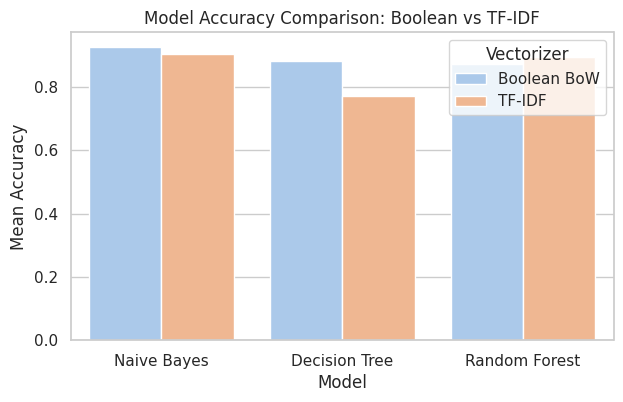

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Combine results
res_boolean['Vectorizer'] = 'Boolean BoW'
res_tfidf['Vectorizer'] = 'TF-IDF'
combined = pd.concat([res_boolean, res_tfidf])

# Extract numeric accuracy for plotting
combined['Accuracy'] = combined['Accuracy (±)'].str.split('±').str[0].astype(float)

plt.figure(figsize=(7,4))
sns.barplot(data=combined, x='Model', y='Accuracy', hue='Vectorizer', palette='pastel')
plt.title("Model Accuracy Comparison: Boolean vs TF-IDF")
plt.ylabel("Mean Accuracy")
plt.show()


# Bar Plot of Performance Metrics

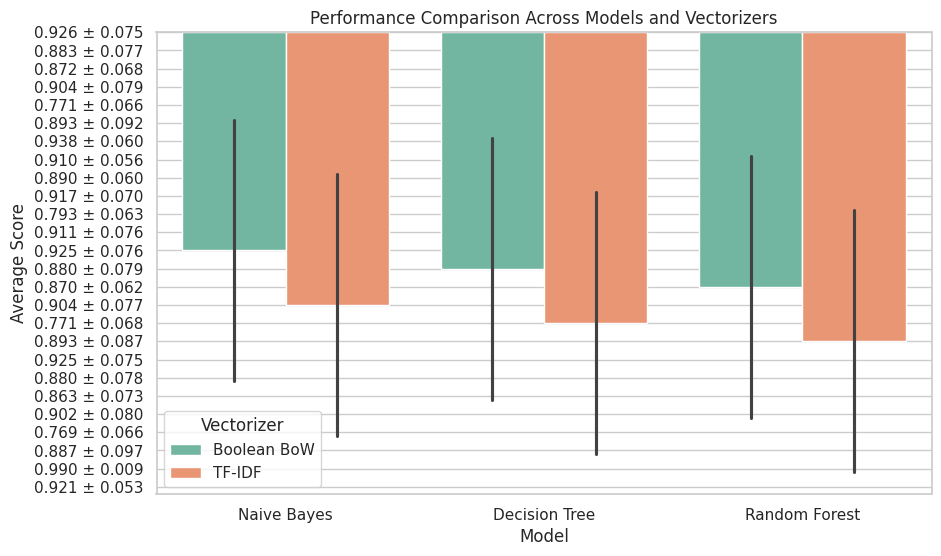

In [ ]:
melted = combined.melt(
    id_vars=['Model','Vectorizer'],
    value_vars=['Accuracy (±)','Precision (±)','Recall (±)','F1 (±)','AUC (±)'],
    var_name='Metric', value_name='Score'
)

plt.figure(figsize=(10,6))
sns.barplot(x='Model', y='Score', hue='Vectorizer', data=melted, palette='Set2')
plt.title("Performance Comparison Across Models and Vectorizers")
plt.ylabel("Average Score")
plt.legend(title="Vectorizer")
plt.show()


# Confusion Matrix for Best Model

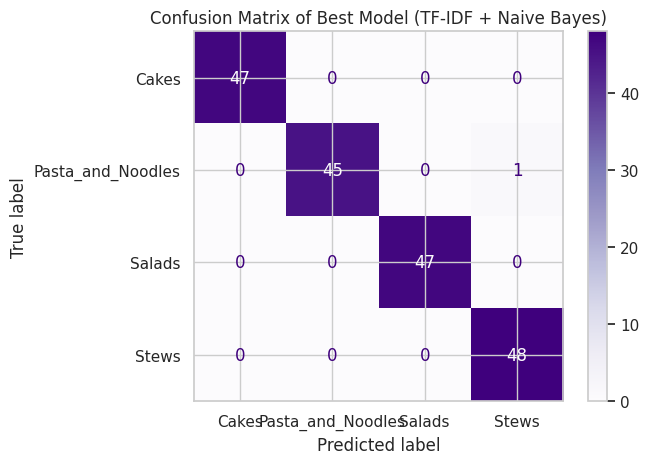

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Example: Run once on full dataset
best_vect = TfidfVectorizer(tokenizer=lemmatize_tokenize, ngram_range=(1,2))
X_vec = best_vect.fit_transform(df['text'])
best_model = MultinomialNB().fit(X_vec, df['label'])
y_pred = best_model.predict(X_vec)

cm = confusion_matrix(df['label'], y_pred, labels=best_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap='Purples')
plt.title("Confusion Matrix of Best Model (TF-IDF + Naive Bayes)")
plt.show()


# Most Frequent Words per Category

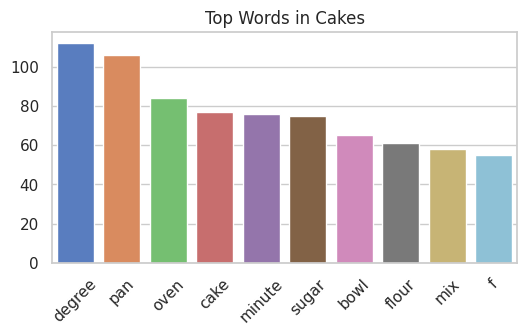

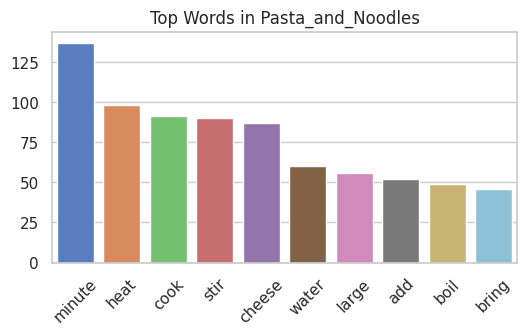

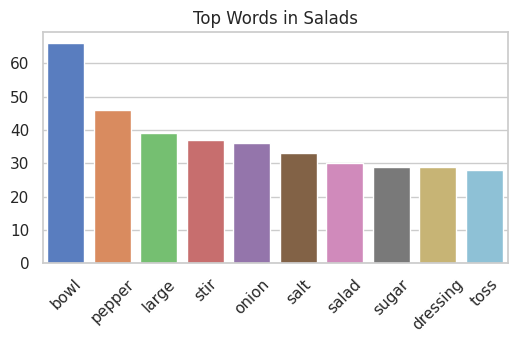

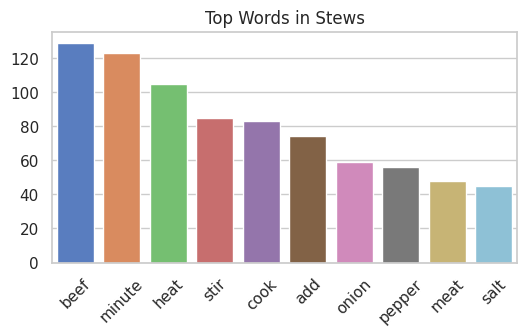

In [ ]:
from collections import Counter
import itertools

for label in df['label'].unique():
    words = list(itertools.chain.from_iterable(df[df['label']==label]['text'].apply(lemmatize_tokenize)))
    common = Counter(words).most_common(10)
    words, counts = zip(*common)
    plt.figure(figsize=(6,3))
    sns.barplot(x=list(words), y=list(counts), palette='muted')
    plt.title(f"Top Words in {label}")
    plt.xticks(rotation=45)
    plt.show()
